In [66]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# 1. Load and preprocess the Fashion-MNIST dataset
fashion_mnist = fetch_openml('Fashion-MNIST')
data, labels = fashion_mnist.data, fashion_mnist.target
data = data / 255.0  # Normalize

In [52]:
# Step 1: Dimensionality Reduction using PCA (further reduced to 10 components)
pca = PCA(n_components=10)
data_reduced = pca.fit_transform(data)

# Use a subset of the data for Hierarchical Clustering (first 10,000 samples)
data_subset = data_reduced[:10000]

In [54]:
# Function to perform Hierarchical Clustering
def agglomerative_clustering(data, linkage_method='ward', num_clusters=10):
    # Perform hierarchical clustering
    Z = linkage(data, method=linkage_method)
    # Extract cluster labels for a specified number of clusters
    labels = fcluster(Z, t=num_clusters, criterion='maxclust')
    return labels, Z

In [56]:
# Function to perform DBSCAN
def dbscan(data, eps=0.5, min_pts=5):
    # Perform DBSCAN clustering
    db = DBSCAN(eps=eps, min_samples=min_pts)
    labels = db.fit_predict(data)
    return labels

In [58]:
# Function to evaluate clustering quality
def evaluate_clusters(data, labels_pred):
    # Calculate Silhouette Score and Davies-Bouldin Score
    silhouette_avg = silhouette_score(data, labels_pred)
    davies_bouldin_avg = davies_bouldin_score(data, labels_pred)
    return silhouette_avg, davies_bouldin_avg

In [60]:
# Function to plot clusters
def plot_clusters(data, labels, title):
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=data[:, 0], y=data[:, 1], hue=labels, palette='viridis', s=10)
    plt.title(title)
    plt.xlabel('PCA Component 1')
    plt.ylabel('PCA Component 2')
    plt.legend(title='Cluster', loc='best')
    plt.show()

In [62]:
# Function to plot dendrogram
def plot_dendrogram(Z):
    plt.figure(figsize=(10, 7))
    dendrogram(Z)
    plt.title("Hierarchical Clustering Dendrogram")
    plt.xlabel("Samples")
    plt.ylabel("Distance")
    plt.show()

Hierarchical Clustering: Silhouette Score = 0.2615634410425972 , Davies-Bouldin Score = 1.2081534395407165


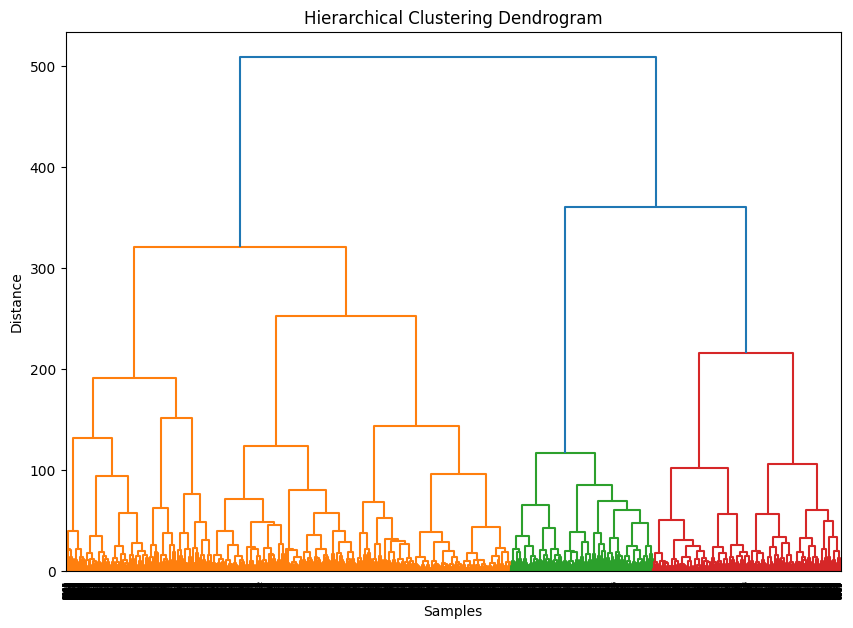

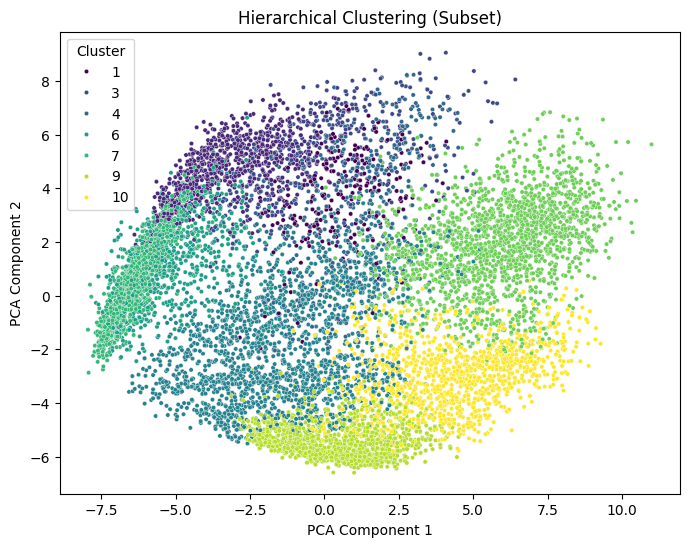

DBSCAN: Silhouette Score = -0.600258057001921 , Davies-Bouldin Score = 1.2616340067370932


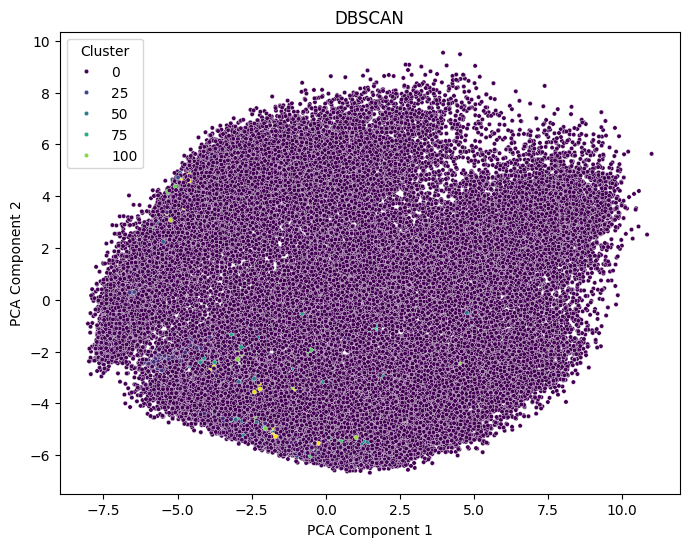

In [68]:
# Run the clustering algorithms, evaluate, and visualize

# Hierarchical Clustering on reduced data subset
labels_hierarchical, Z = agglomerative_clustering(data_subset)
silhouette_hier, db_hier = evaluate_clusters(data_subset, labels_hierarchical)
print("Hierarchical Clustering: Silhouette Score =", silhouette_hier, ", Davies-Bouldin Score =", db_hier)
plot_dendrogram(Z)  # Plot the dendrogram
plot_clusters(data_subset, labels_hierarchical, "Hierarchical Clustering (Subset)")

# DBSCAN on entire reduced data
labels_dbscan = dbscan(data_reduced, eps=0.5, min_pts=5)
silhouette_dbscan, db_dbscan = evaluate_clusters(data_reduced, labels_dbscan)
print("DBSCAN: Silhouette Score =", silhouette_dbscan, ", Davies-Bouldin Score =", db_dbscan)
plot_clusters(data_reduced, labels_dbscan, "DBSCAN")